In [3]:
import pandas as pd
import glob

In [4]:
import pandas as pd

data = pd.read_csv(r"../data/data_methaq(2.0).csv")

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = [x.upper() if isinstance(x, str) else x for x in data[col]]

print(data.head())

       chassisNumber    year    make    model trim            bodyType  \
0  RKLBB9HE7F5115863  2015.0  TOYOTA  COROLLA   SE               SEDAN   
1  JTFHX02POF0099797  2015.0  TOYOTA    HIACE  GLX  MINI BUS HIGH ROOF   
2  JTFHX02P7F0094323  2015.0  TOYOTA    HIACE   DX  MINI BUS HIGH ROOF   
3  JTFHXDGP7F0094373  2015.0  TOYOTA    HILUX   DL  PICK UP DOUBLE CAB   
4  4T1BG22K01U789089  2001.0  TOYOTA    CAMRY  XLI               SEDAN   

  regionalSpec  cylinders            color  origin  weightInKg  noOfPassengers  
0          GCC        4.0           SILVER  TAIWAN      1000.0             5.0  
1          GCC        4.0            WHITE   JAPAN      2000.0             2.0  
2          GCC        4.0            WHITE   JAPAN      1837.0            15.0  
3          GCC        4.0            WHITE   JAPAN      1837.0             5.0  
4      NON-GCC        4.0  BROWN AND BEIGE   JAPAN      1481.0             5.0  


In [5]:
data = data[data["make"] == "TOYOTA"]
data

,chassisNumber,year,make,model,trim,bodyType,regionalSpec,cylinders,color,origin,weightInKg,noOfPassengers
0,RKLBB9HE7F5115863,2015.0,TOYOTA,COROLLA,SE,SEDAN,GCC,4.0,SILVER,TAIWAN,1000.0,5.0
1,JTFHX02POF0099797,2015.0,TOYOTA,HIACE,GLX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,2000.0,2.0
2,JTFHX02P7F0094323,2015.0,TOYOTA,HIACE,DX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,1837.0,15.0
3,JTFHXDGP7F0094373,2015.0,TOYOTA,HILUX,DL,PICK UP DOUBLE CAB,GCC,4.0,WHITE,JAPAN,1837.0,5.0
4,4T1BG22K01U789089,2001.0,TOYOTA,CAMRY,XLI,SEDAN,NON-GCC,4.0,BROWN AND BEIGE,JAPAN,1481.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
922350,MR0HU8CDXK0071134,2019.0,TOYOTA,HILUX,GLX,PICKUP,GCC,6.0,WHITE/PEARLS,NaN,NaN,5.0
922351,JTMABBBJ6S4188504,2025.0,TOYOTA,LAND CRUISER,1,SUV,GCC,6.0,BLACK,NaN,NaN,7.0
922352,JTMHX01J3M4222343,2021.0,TOYOTA,LAND CRUISER,GXR,SUV,GCC,8.0,WHITE/PEARLS,NaN,NaN,8.0
922353,JTEAACAJ1S5008118,2025.0,TOYOTA,LAND CRUISER PRADO,GXL,SUV,GCC,4.0,WHITE/PEARLS,NaN,NaN,7.0


In [4]:
data["chassis_len"] = data["chassisNumber"].str.len()
data["pos10"] = data["chassisNumber"].str[9]

is_standard = (data["chassis_len"] == 17) & (~data["pos10"].isin(['I', 'O', 'Q', 'U', 'Z', '0']))
data = data[is_standard]
data


,chassisNumber,year,make,model,trim,bodyType,regionalSpec,cylinders,color,origin,weightInKg,noOfPassengers,chassis_len,pos10
0,RKLBB9HE7F5115863,2015.0,TOYOTA,COROLLA,SE,SEDAN,GCC,4.0,SILVER,TAIWAN,1000.0,5.0,17,F
1,JTFHX02POF0099797,2015.0,TOYOTA,HIACE,GLX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,2000.0,2.0,17,F
2,JTFHX02P7F0094323,2015.0,TOYOTA,HIACE,DX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,1837.0,15.0,17,F
3,JTFHXDGP7F0094373,2015.0,TOYOTA,HILUX,DL,PICK UP DOUBLE CAB,GCC,4.0,WHITE,JAPAN,1837.0,5.0,17,F
4,4T1BG22K01U789089,2001.0,TOYOTA,CAMRY,XLI,SEDAN,NON-GCC,4.0,BROWN AND BEIGE,JAPAN,1481.0,5.0,17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922350,MR0HU8CDXK0071134,2019.0,TOYOTA,HILUX,GLX,PICKUP,GCC,6.0,WHITE/PEARLS,NaN,NaN,5.0,17,K
922351,JTMABBBJ6S4188504,2025.0,TOYOTA,LAND CRUISER,1,SUV,GCC,6.0,BLACK,NaN,NaN,7.0,17,S
922352,JTMHX01J3M4222343,2021.0,TOYOTA,LAND CRUISER,GXR,SUV,GCC,8.0,WHITE/PEARLS,NaN,NaN,8.0,17,M
922353,JTEAACAJ1S5008118,2025.0,TOYOTA,LAND CRUISER PRADO,GXL,SUV,GCC,4.0,WHITE/PEARLS,NaN,NaN,7.0,17,S


In [5]:
# 1. World Manufacturer Identifier (WMI)
data["WMI"] = data["chassisNumber"].str[0:3]
data["pos1"] = data["chassisNumber"].str[0]
data["pos2"] = data["chassisNumber"].str[1]
data["pos3"] = data["chassisNumber"].str[2]

# 2. Vehicle Descriptor Section (VDS)
data["VDS"] = data["chassisNumber"].str[3:8]  # Standard VIN uses positions 4-9 (index 3:9)
data["pos4"] = data["chassisNumber"].str[3]
data["pos5"] = data["chassisNumber"].str[4]
data["pos6"] = data["chassisNumber"].str[5]
data["pos7"] = data["chassisNumber"].str[6]
data["pos8"] = data["chassisNumber"].str[7]
data["pos9"] = data["chassisNumber"].str[8]  # Check Digit

# 3. Vehicle Identifier Section (VIS)
data["VIS"] = data["chassisNumber"].str[9:17]  # Standard VIN uses positions 10-17 (index 9:17)
data["Model_Year"] = data["chassisNumber"].str[9]  # Model Year
data["Plant_Code"] = data["chassisNumber"].str[10]  # Plant Code

# 4. Production Serial Number (Last 6 digits of VIS)
data["Serial_Number"] = data["chassisNumber"].str[11:17]

C:\Users\Admin\AppData\Local\Temp\ipykernel_8076\2788717906.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["WMI"] = data["chassisNumber"].str[0:3]
C:\Users\Admin\AppData\Local\Temp\ipykernel_8076\2788717906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["pos1"] = data["chassisNumber"].str[0]
C:\Users\Admin\AppData\Local\Temp\ipykernel_8076\2788717906.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [6]:
data

,chassisNumber,year,make,model,trim,bodyType,regionalSpec,cylinders,color,origin,...,pos4,pos5,pos6,pos7,pos8,pos9,VIS,Model_Year,Plant_Code,Serial_Number
0,RKLBB9HE7F5115863,2015.0,TOYOTA,COROLLA,SE,SEDAN,GCC,4.0,SILVER,TAIWAN,...,B,B,9,H,E,7,F5115863,F,5,115863
1,JTFHX02POF0099797,2015.0,TOYOTA,HIACE,GLX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,...,H,X,0,2,P,O,F0099797,F,0,099797
2,JTFHX02P7F0094323,2015.0,TOYOTA,HIACE,DX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,...,H,X,0,2,P,7,F0094323,F,0,094323
3,JTFHXDGP7F0094373,2015.0,TOYOTA,HILUX,DL,PICK UP DOUBLE CAB,GCC,4.0,WHITE,JAPAN,...,H,X,D,G,P,7,F0094373,F,0,094373
4,4T1BG22K01U789089,2001.0,TOYOTA,CAMRY,XLI,SEDAN,NON-GCC,4.0,BROWN AND BEIGE,JAPAN,...,B,G,2,2,K,0,1U789089,1,U,789089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922350,MR0HU8CDXK0071134,2019.0,TOYOTA,HILUX,GLX,PICKUP,GCC,6.0,WHITE/PEARLS,NaN,...,H,U,8,C,D,X,K0071134,K,0,071134
922351,JTMABBBJ6S4188504,2025.0,TOYOTA,LAND CRUISER,1,SUV,GCC,6.0,BLACK,NaN,...,A,B,B,B,J,6,S4188504,S,4,188504
922352,JTMHX01J3M4222343,2021.0,TOYOTA,LAND CRUISER,GXR,SUV,GCC,8.0,WHITE/PEARLS,NaN,...,H,X,0,1,J,3,M4222343,M,4,222343
922353,JTEAACAJ1S5008118,2025.0,TOYOTA,LAND CRUISER PRADO,GXL,SUV,GCC,4.0,WHITE/PEARLS,NaN,...,A,A,C,A,J,1,S5008118,S,5,008118


In [7]:
origin_mapping = {
    "1": "USA",
    "4": "USA",
    "5": "USA",
    "2": "CANADA",
    "3": "MEXICO",
    "J": "JAPAN",
    "K": "SOUTH KOREA",
    "W": "GERMANY",
    "Z": "ITALY",
    "S": "UNITED KINGDOM",
    "Y": "SWEDEN / FINLAND",
    "L": "CHINA",
    "M": "INDIA",
    "V": "FRANCE / SPAIN",
    "T": "SWITZERLAND",
    "R": "TAIWAN",
    "9": "BRAZIL"
}

In [8]:
data["origin"] = data["pos1"].map(origin_mapping).fillna(data["origin"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_8076\3808071572.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["origin"] = data["pos1"].map(origin_mapping).fillna(data["origin"])


In [9]:
data

,chassisNumber,year,make,model,trim,bodyType,regionalSpec,cylinders,color,origin,...,pos4,pos5,pos6,pos7,pos8,pos9,VIS,Model_Year,Plant_Code,Serial_Number
0,RKLBB9HE7F5115863,2015.0,TOYOTA,COROLLA,SE,SEDAN,GCC,4.0,SILVER,TAIWAN,...,B,B,9,H,E,7,F5115863,F,5,115863
1,JTFHX02POF0099797,2015.0,TOYOTA,HIACE,GLX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,...,H,X,0,2,P,O,F0099797,F,0,099797
2,JTFHX02P7F0094323,2015.0,TOYOTA,HIACE,DX,MINI BUS HIGH ROOF,GCC,4.0,WHITE,JAPAN,...,H,X,0,2,P,7,F0094323,F,0,094323
3,JTFHXDGP7F0094373,2015.0,TOYOTA,HILUX,DL,PICK UP DOUBLE CAB,GCC,4.0,WHITE,JAPAN,...,H,X,D,G,P,7,F0094373,F,0,094373
4,4T1BG22K01U789089,2001.0,TOYOTA,CAMRY,XLI,SEDAN,NON-GCC,4.0,BROWN AND BEIGE,USA,...,B,G,2,2,K,0,1U789089,1,U,789089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922350,MR0HU8CDXK0071134,2019.0,TOYOTA,HILUX,GLX,PICKUP,GCC,6.0,WHITE/PEARLS,INDIA,...,H,U,8,C,D,X,K0071134,K,0,071134
922351,JTMABBBJ6S4188504,2025.0,TOYOTA,LAND CRUISER,1,SUV,GCC,6.0,BLACK,JAPAN,...,A,B,B,B,J,6,S4188504,S,4,188504
922352,JTMHX01J3M4222343,2021.0,TOYOTA,LAND CRUISER,GXR,SUV,GCC,8.0,WHITE/PEARLS,JAPAN,...,H,X,0,1,J,3,M4222343,M,4,222343
922353,JTEAACAJ1S5008118,2025.0,TOYOTA,LAND CRUISER PRADO,GXL,SUV,GCC,4.0,WHITE/PEARLS,JAPAN,...,A,A,C,A,J,1,S5008118,S,5,008118


In [10]:
print(data['origin'].unique())

['TAIWAN' 'JAPAN' 'USA' 'INDIA' 'AUSTRALIA' 'CANADA' 'GERMANY' 'CHINA'
 'TURKEY' 'MEXICO' 'REPUBLIC OF TURKIYE' 'UNITED STATES' 'ITALY' 'SPAIN'
 'SOUTH KOREA' 'UNITED KINGDOM' 'FRANCE / SPAIN' 'UAE' 'SWEDEN / FINLAND'
 'INDONESIA' 'AMERICA' 'AUSTRIA' nan 'NEW ZEALAND' 'استراليا'
 'SWITZERLAND' 'BRAZIL' 'ESTONIA' 'SOUTH AFRICA' 'GCC' 'SWEDEN' 'THAILAND'
 'UNITED ARAB EMIRATES' 'EGYPT' 'ASIAN' 'J' 'MOROCCO' 'ORIGIN' 'D'
 'AUSTRALLA' 'FAUSTRALIA' 'GREAT BRITAIN' 'SUDAN' 'MACAU' 'LADIR'
 'REPUBLIC OF SOUTH KOREA' 'KOREA']


In [11]:
print(data['bodyType'].unique())

['SEDAN' 'MINI BUS HIGH ROOF' 'PICK UP DOUBLE CAB' 'SUV' 'HATCHBACK'
 'PICK UP SINGLE CAB' 'PANEL VAN' 'BUS' 'MPV' 'ESTATE' 'PICK UP' 'VAN'
 'MINI BUS' 'COUPE' 'SUV- CROSSOVER' 'PICKUP' 'SALOON'
 'PANEL VAN HIGH ROOF' 'STATION' 'HALF PANEL VAN' 'CONVERTIBLE'
 'CARGO VAN' 'MINIVAN' 'MINI BUS SEMI HIGH ROOF' 'CARAVAN' 'PICKUP TRUCK'
 'LIGHT VEHICLE' 'MOTORCYCLE' 'PICKUP SINGLE CABIN' 'TRUCK'
 'PICK UP DOUBLE CABIN' 'PICKUP DOUBLE CABIN' 'COUPE/CABRIOLET'
 'AMBULANCE' 'REGULAR CAB' 'PICKUP DOUBLE CAB' 'WINDOW VAN' 'WAGON'
 'PICK-UP']


In [12]:
! pip install catboost -q


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

## Origin

In [14]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'origin'

In [15]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize and clean up rare classes in 'origin'
df_model['origin'] = df_model['origin'].replace({
    'UNITED STATES': 'USA',
    'AMERICA': 'USA',
    'REPUBLIC OF SOUTH KOREA': 'SOUTH KOREA',
    'KOREA': 'SOUTH KOREA',
    'UNITED ARAB EMIRATES': 'UAE',
    'AUSTRALLA': 'AUSTRALIA',
    'FAUSTRALIA': 'AUSTRALIA',
    'استراليا': 'AUSTRALIA',
    'J': 'JAPAN',
})

# Filter out classes with fewer than 10 instances to avoid missing classes in train/test splits
origin_counts = df_model['origin'].value_counts()
valid_origins = origin_counts[origin_counts >= 10].index
df_model = df_model[df_model['origin'].isin(valid_origins)]

df_model = df_model.dropna()

print(df_model.shape)

(237690, 12)


In [16]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(190152, 11)
(47538, 11)


In [17]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [18]:
model = CatBoostClassifier(
    iterations=100,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	learn: 0.9037559	test: 0.9045395	best: 0.9045395 (0)	total: 10.9s	remaining: 17m 57s


KeyboardInterrupt: 

In [ ]:
preds = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9912


In [ ]:
print(
    classification_report(
        y_test,
        preds
    )
)

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                     precision    recall  f1-score   support

          AUSTRALIA       0.92      1.00      0.96      4635
            AUSTRIA       0.00      0.00      0.00         6
             CANADA       1.00      1.00      1.00       921
              CHINA       1.00      0.99      0.99       150
     FRANCE / SPAIN       1.00      1.00      1.00        24
            GERMANY       1.00      1.00      1.00        55
              INDIA       1.00      1.00      1.00      7550
              ITALY       1.00      1.00      1.00        20
              JAPAN       1.00      0.98      0.99     22981
             MEXICO       1.00      1.00      1.00        63
REPUBLIC OF TURKIYE       0.00      0.00      0.00        16
        SOUTH KOREA       1.00      1.00      1.00        18
   SWEDEN / FINLAND       1.00      1.00      1.00        10
             TAIWAN       1.00      1.00      1.00      3421
             TURKEY       0.74      1.00      0.85        49
                UAE    

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,pos1,99.220527
9,Model_Year,0.779473
1,pos2,0.000000
2,pos3,0.000000
3,pos4,0.000000
5,pos6,0.000000
4,pos5,0.000000
6,pos7,0.000000
7,pos8,0.000000
8,pos9,0.000000


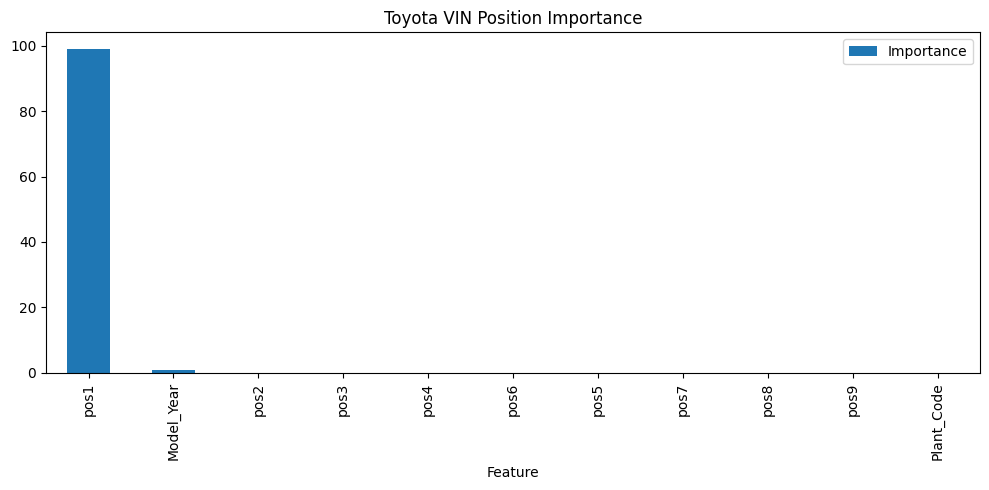

In [ ]:
import matplotlib.pyplot as plt

importance_df.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Toyota VIN Position Importance")
plt.tight_layout()
plt.show()

## Model

In [ ]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'model'

In [ ]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize model names
df_model['model'] = (
    df_model['model']
    .astype(str)
    .str.upper()
    .str.strip()
)

# Merge common variants / spelling issues
df_model['model'] = df_model['model'].replace({
    'HI ACE': 'HIACE',
    'TOYOTA HIACE': 'HIACE',

    'LAND CRUISE': 'LAND CRUISER',
    'LAND CRUISER GX': 'LAND CRUISER',
    'LAND CRUISER GXR': 'LAND CRUISER',
    'LAND CRUISER VXR': 'LAND CRUISER',

    'TOKOMA': 'TACOMA',
    'TAKOMA PICK UP CARGO': 'TACOMA',
    'TACOMA (PICK UP)': 'TACOMA',

    'TOYOTA COROLLA 1.6': 'COROLLA',
    'TOYOTA COROLLA 1.8': 'COROLLA',
    'TOYOTA COROLLA 2.0': 'COROLLA',
    'COROLLA 1.5': 'COROLLA',
    'COROLLA 1.6/SEDAN': 'COROLLA',
    'COROLLA LI': 'COROLLA',

    'TOYOTA HILUX': 'HILUX',
    'HILUX RE': 'HILUX',

    'SIENA': 'SIENNA',
    'SIENNA(VAN)': 'SIENNA',
    'SIENNA VAN': 'SIENNA',

    'TOYOTA PRIUS': 'PRIUS',
    'TOYOTA SUPRA': 'SUPRA',
    'TOYOTA RUSH': 'RUSH',
    'TOYOTA TUNDRA': 'TUNDRA',
})

# Remove rare classes
model_counts = df_model['model'].value_counts()

valid_models = model_counts[
    model_counts >= 10
].index

df_model = df_model[
    df_model['model'].isin(valid_models)
]

df_model = df_model.dropna()

print(df_model.shape)

# Check remaining models
print(df_model['model'].nunique())
print(df_model['model'].value_counts().head(20))

(238975, 12)
61
model
CAMRY           50359
COROLLA         38025
LAND CRUISER    32163
YARIS           23246
HILUX           16700
RAV4            11959
HIACE           11748
PRADO            7798
SIENNA           6839
FORTUNER         5339
AVALON           4557
TUNDRA           4333
FJ CRUISER       2954
INNOVA           2687
RUSH             2409
PREVIA           2032
PRIUS            1549
AVANZA           1517
CAMRY HYBRID     1379
SEQUOIA          1050
Name: count, dtype: int64


In [ ]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(191180, 11)
(47795, 11)


In [ ]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
model = CatBoostClassifier(
    iterations=10,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	learn: 0.8234596	test: 0.8267601	best: 0.8267601 (0)	total: 2m 41s	remaining: 24m 15s
9:	learn: 0.8539439	test: 0.8570980	best: 0.8570980 (9)	total: 29m 8s	remaining: 0us

bestTest = 0.8570980228
bestIteration = 9



CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=10, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [ ]:
preds = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8571


In [ ]:
print(
    classification_report(
        y_test,
        preds
    )
)

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                        precision    recall  f1-score   support

              4 RUNNER       0.00      0.00      0.00         2
               4RUNNER       0.00      0.00      0.00        51
                    86       0.00      0.00      0.00        52
               ALPHARD       0.00      0.00      0.00         3
                AURION       0.00      0.00      0.00       197
                AVALON       0.62      1.00      0.77       911
                AVANZA       0.00      0.00      0.00       303
                  BZ4X       0.00      0.00      0.00         5
                  C-HR       0.96      0.99      0.98        82
                 CAMRY       0.95      0.99      0.97     10072
          CAMRY HYBRID       0.00      0.00      0.00       276
               COASTER       0.00      0.00      0.00       110
               COROLLA       0.99      0.97      0.98      7605
           COROLLA 1.3       0.00      0.00      0.00         4
           COROLLA 1.6       0.00      

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
7,pos8,100.0
1,pos2,0.0
0,pos1,0.0
2,pos3,0.0
3,pos4,0.0
5,pos6,0.0
4,pos5,0.0
6,pos7,0.0
8,pos9,0.0
9,Model_Year,0.0


In [ ]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'trim'

In [ ]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize target
df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove rare classes
counts = df_model[target_col].value_counts()

valid_classes = counts[
    counts >= 10
].index

df_model = df_model[
    df_model[target_col].isin(valid_classes)
]

print("Remaining classes:",
      df_model[target_col].nunique())

print("Rows:",
      len(df_model))

Remaining classes: 158
Rows: 238823


In [ ]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(191058, 11)
(47765, 11)


In [ ]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
model = CatBoostClassifier(
    iterations=5,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

CatBoostError: bad allocation

In [ ]:
print(df_model.memory_usage(deep=True).sum() / 1024**2)

139.11834907531738


In [19]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'year'

In [20]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize target
df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove rare classes
counts = df_model[target_col].value_counts()

valid_classes = counts[
    counts >= 10
].index

df_model = df_model[
    df_model[target_col].isin(valid_classes)
]

print("Remaining classes:",
      df_model[target_col].nunique())

print("Rows:",
      len(df_model))

Remaining classes: 33
Rows: 239178


In [21]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(191342, 11)
(47836, 11)


In [22]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [23]:
model = CatBoostClassifier(
    iterations=10,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	learn: 0.4499483	test: 0.4498495	best: 0.4498495 (0)	total: 47.9s	remaining: 3m 11s
4:	learn: 0.7767505	test: 0.7765699	best: 0.7765699 (4)	total: 3m 55s	remaining: 0us

bestTest = 0.7765699473
bestIteration = 4



CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=5, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [24]:
preds = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7766


In [25]:
print(
    classification_report(
        y_test,
        preds
    )
)

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      1994.0       0.00      0.00      0.00         3
      1995.0       0.00      0.00      0.00         4
      1996.0       0.00      0.00      0.00         9
      1997.0       0.00      0.00      0.00       131
      1998.0       0.00      0.00      0.00       279
      1999.0       0.00      0.00      0.00       437
      2000.0       0.00      0.00      0.00       517
      2001.0       0.00      0.00      0.00       617
      2002.0       0.00      0.00      0.00       738
      2003.0       0.28      1.00      0.44      1074
      2004.0       1.00      1.00      1.00      1556
      2005.0       1.00      0.99      0.99      2057
      2006.0       0.99      0.99      0.99      2303
      2007.0       1.00      0.99      1.00      2570
      2008.0       1.00      0.99      0.99      3643
      2009.0       1.00      1.00      1.00      2868
      2010.0       1.00      1.00      1.00      2309
      2011.0       0.99    

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [26]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
9,Model_Year,100.0
1,pos2,0.0
0,pos1,0.0
2,pos3,0.0
3,pos4,0.0
5,pos6,0.0
4,pos5,0.0
6,pos7,0.0
7,pos8,0.0
8,pos9,0.0


In [29]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'cylinders'

In [30]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize target
df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove rare classes
counts = df_model[target_col].value_counts()

valid_classes = counts[
    counts >= 10
].index

df_model = df_model[
    df_model[target_col].isin(valid_classes)
]

print("Remaining classes:",
      df_model[target_col].nunique())

print("Rows:",
      len(df_model))

Remaining classes: 6
Rows: 239214


In [31]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(191371, 11)
(47843, 11)


In [32]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [33]:
model = CatBoostClassifier(
    iterations=5,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	learn: 0.8597489	test: 0.8610873	best: 0.8610873 (0)	total: 2.14s	remaining: 8.55s
4:	learn: 0.8604020	test: 0.8612336	best: 0.8612336 (1)	total: 10s	remaining: 0us

bestTest = 0.8612336183
bestIteration = 1

Shrink model to first 2 iterations.


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=5, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [34]:
preds = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8612


In [35]:
print(
    classification_report(
        y_test,
        preds
    )
)

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        18
         3.0       0.00      0.00      0.00       258
         4.0       0.94      0.96      0.95     34485
         6.0       0.64      0.76      0.69      9321
         8.0       0.76      0.27      0.40      3752
         NAN       0.00      0.00      0.00         9

    accuracy                           0.86     47843
   macro avg       0.39      0.33      0.34     47843
weighted avg       0.86      0.86      0.85     47843



C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [36]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
7,pos8,100.0
1,pos2,0.0
0,pos1,0.0
2,pos3,0.0
3,pos4,0.0
5,pos6,0.0
4,pos5,0.0
6,pos7,0.0
8,pos9,0.0
9,Model_Year,0.0


In [7]:
feature_cols = [
    'pos1',
    'pos2',
    'pos3',
    'pos4',
    'pos5',
    'pos6',
    'pos7',
    'pos8',
    'pos9',
    'Model_Year',
    'Plant_Code'
]

target_col = 'regionalSpec'

In [8]:
df_model = data[
    feature_cols + [target_col]
].copy()

# Standardize target
df_model[target_col] = (
    df_model[target_col]
    .astype(str)
    .str.upper()
    .str.strip()
)

# Remove rare classes
counts = df_model[target_col].value_counts()

valid_classes = counts[
    counts >= 10
].index

df_model = df_model[
    df_model[target_col].isin(valid_classes)
]

print("Remaining classes:",
      df_model[target_col].nunique())

print("Rows:",
      len(df_model))

KeyError: "['pos1', 'pos2', 'pos3', 'pos4', 'pos5', 'pos6', 'pos7', 'pos8', 'pos9', 'Model_Year', 'Plant_Code'] not in index"

In [39]:
X = df_model[feature_cols]

y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(187492, 11)
(46873, 11)


In [40]:
cat_features = list(range(len(feature_cols)))

print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
model = CatBoostClassifier(
    iterations=10,
    depth=8,
    learning_rate=0.05,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    verbose=100,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

In [ ]:
preds = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

print(f"Accuracy: {accuracy:.4f}")

In [ ]:
print(
    classification_report(
        y_test,
        preds
    )
)

In [ ]:
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df